## CREDIT RISK PREDICTION

By: Nazly Rafa Oktafian Nuzqu

#### BUSINESS PROBLEM UNDERSTANDING

As a Data Scientist at ID/X Partners, I am working on a project for a multifinance/lending company client. The client aims to improve the accuracy of their credit risk assessment and management processes. By developing a robust predictive model, the company can:

- Optimize business decisions regarding loan approvals
- Reduce potential financial losses from defaults
- Better evaluate creditworthiness of loan applicants
- Enhance overall risk management strategy

Dataset Overview
The project uses a Loan Dataset with accompanying Data Dictionary that includes:

- Approved loans data - Loans that were granted to borrowers
- Rejected loans data - Loan applications that were declined
- Credit performance indicators - Historical payment behavior and credit status
- Borrower characteristics - Various attributes of loan applicants

The dataset requires analysis to identify credit performance columns and determine labels (GOOD/BAD credit) based on payment history and delinquency patterns.



#### IMPORT LIBRARIES

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,fbeta_score,precision_score, recall_score, f1_score, fbeta_score,classification_report, roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier


#### LOAD DATASET

Feature Description: https://docs.google.com/spreadsheets/d/1iT1JNOBwU4l616_rnJpo0iny7blZvNBs/edit?gid=1666154857#gid=1666154857 

In [80]:
path = r"C:\Users\Rafa\OneDrive - ypt.or.id\Documents\Data Scientist IDX Partners\FinalProjectIDXPartners/loan_data_2007_2014.csv"
df = pd.read_csv(path)
df.head()

C:\Users\Rafa\AppData\Local\Temp\ipykernel_9796\1246474143.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### DATA UNDERSTANDING

In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [82]:
df.columns

Index(['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt',
       'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade',
       'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url',
       'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths',
       'mths_since_last_delinq', 'mths_since_last_record', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int',
       'total_rec_late_fee', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d',
       'collections_12_mths_ex_med', 'mths_since_last_major_derog',
       'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint',
       'verificatio

In [83]:
df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,...,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,...,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,...,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,...,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,...,NaN,NaN,NaN,NaN,NaN,NaN,3.790000e+04,NaN,NaN,NaN
max,466284.000000,3.809811e+07,4.086083e+07,35000.000000,35000.000000,35000.000000,26.060000,1409.990000,7.500000e+06,39.990000,...,NaN,NaN,NaN,NaN,NaN,NaN,9.999999e+06,NaN,NaN,NaN


In [84]:
df.shape

(466285, 75)

In [85]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

                             Missing Count  Missing (%)
max_bal_bc                          466285   100.000000
open_rv_24m                         466285   100.000000
inq_fi                              466285   100.000000
open_rv_12m                         466285   100.000000
il_util                             466285   100.000000
mths_since_rcnt_il                  466285   100.000000
total_bal_il                        466285   100.000000
open_il_24m                         466285   100.000000
open_il_12m                         466285   100.000000
open_il_6m                          466285   100.000000
open_acc_6m                         466285   100.000000
dti_joint                           466285   100.000000
annual_inc_joint                    466285   100.000000
verification_status_joint           466285   100.000000
all_util                            466285   100.000000
inq_last_12m                        466285   100.000000
total_cu_tl                         466285   100

Dalam dataset di atas, terdapat beberapa feature yang memiliki persentase missing values yang tinggi bahkan 100%, untuk handling missing values pada feature yang memiliki persentase > 30% akan di drop / hapus. Kemudian untuk feature dengan persentase missing values < 30% akan dilakukan imputasi menggunakan median / mean.

In [86]:
df.duplicated().sum()

np.int64(0)

Tidak terdapat duplikasi data pada dataset tersebut

In [87]:
df['loan_status'].value_counts()

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64

Analisis isi / nilai dari feature 'loan_status' sebagai acuan penentuan target dapat dikelompokkan menjadi good / bad credit risk prediction. Berdasarkan value dari loan status tersebut, dapat dikelompokkan untuk nilai target seperti berikut:

Good (0): 
- Fully Paid
- Does not meet the credit policy. Status: Fully Paid

Bad (1): 
- Deafault
- Charged Off
- Does not meet the credit policy. Status: Charged Off
- Late (31-120 days)

#### EXPLORATORY DATA ANALYSIS

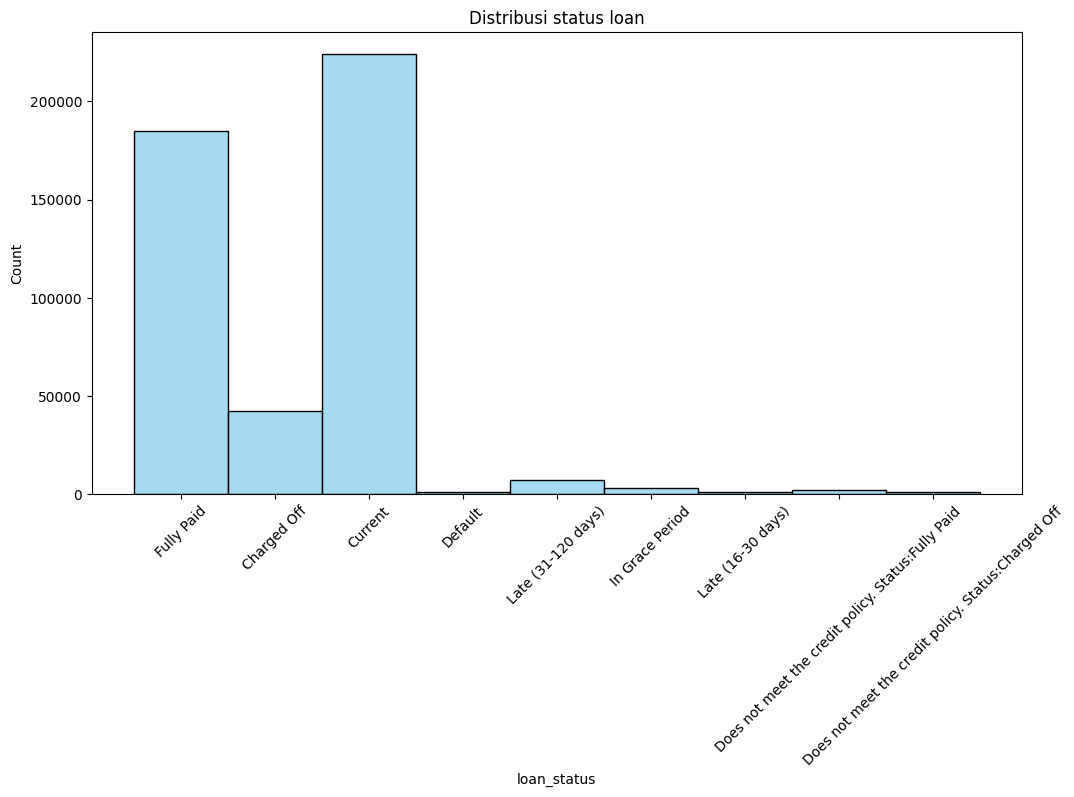

loan_status
Current                                                224226
Fully Paid                                             184739
Charged Off                                             42475
Late (31-120 days)                                       6900
In Grace Period                                          3146
Does not meet the credit policy. Status:Fully Paid       1988
Late (16-30 days)                                        1218
Default                                                   832
Does not meet the credit policy. Status:Charged Off       761
Name: count, dtype: int64


In [88]:
plt.figure(figsize=(12,6))
sns.histplot(df['loan_status'],bins=8, color='skyblue')
plt.title('Distribusi status loan')
plt.xticks(rotation=45)
plt.show()

print(df['loan_status'].value_counts())

In [89]:
df_model = df
df_model.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,...,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [90]:
df_model.drop([
    'id', 'member_id', 'url', 'title', 'zip_code', 'emp_title',
    'recoveries', 'collection_recovery_fee', 'application_type',
    'issue_d', 'pymnt_plan', 'out_prncp', 'out_prncp_inv',
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'last_pymnt_d',
    'last_pymnt_amnt', 'last_credit_pull_d', 'sub_grade',
    'funded_amnt', 'funded_amnt_inv', 'policy_code',
    'addr_state', 'earliest_cr_line','Unnamed: 0',

    # missing value
    'max_bal_bc', 'open_rv_24m', 'inq_fi', 'open_rv_12m',
    'il_util', 'mths_since_rcnt_il', 'total_bal_il',
    'open_il_24m', 'open_il_12m', 'open_il_6m',
    'open_acc_6m', 'dti_joint', 'annual_inc_joint',
    'verification_status_joint', 'all_util', 'inq_last_12m',
    'total_cu_tl', 'mths_since_last_record',
    'mths_since_last_major_derog', 'desc',
    'mths_since_last_delinq','next_pymnt_d','initial_list_status'

], axis=1, inplace=True)

Menghapus feature yang tidak berguna untuk menentukan hasil prediksi seperti fetaure menggunakan 'id', 'link' ataupun missing values dengan persentase > 30%

In [91]:
df_model.shape

(466285, 24)

In [92]:
df_model.isnull().sum()

loan_amnt                         0
term                              0
int_rate                          0
installment                       0
grade                             0
emp_length                    21008
home_ownership                    0
annual_inc                        4
verification_status               0
loan_status                       0
purpose                           0
dti                               0
delinq_2yrs                      29
inq_last_6mths                   29
open_acc                         29
pub_rec                          29
revol_bal                         0
revol_util                      340
total_acc                        29
collections_12_mths_ex_med      145
acc_now_delinq                   29
tot_coll_amt                  70276
tot_cur_bal                   70276
total_rev_hi_lim              70276
dtype: int64

In [93]:
df_model['loan_label'] = np.where(df_model.loc[:, 'loan_status'].isin(['Charged Off', 'Default', 'Late (31-120 days)','Does not meet the credit policy. Status:Charged Off']), 0, 1)
df_model.drop(columns = ['loan_status'], inplace = True)
     

In [94]:
print(df_model['loan_label'].value_counts())

loan_label
1    415317
0     50968
Name: count, dtype: int64


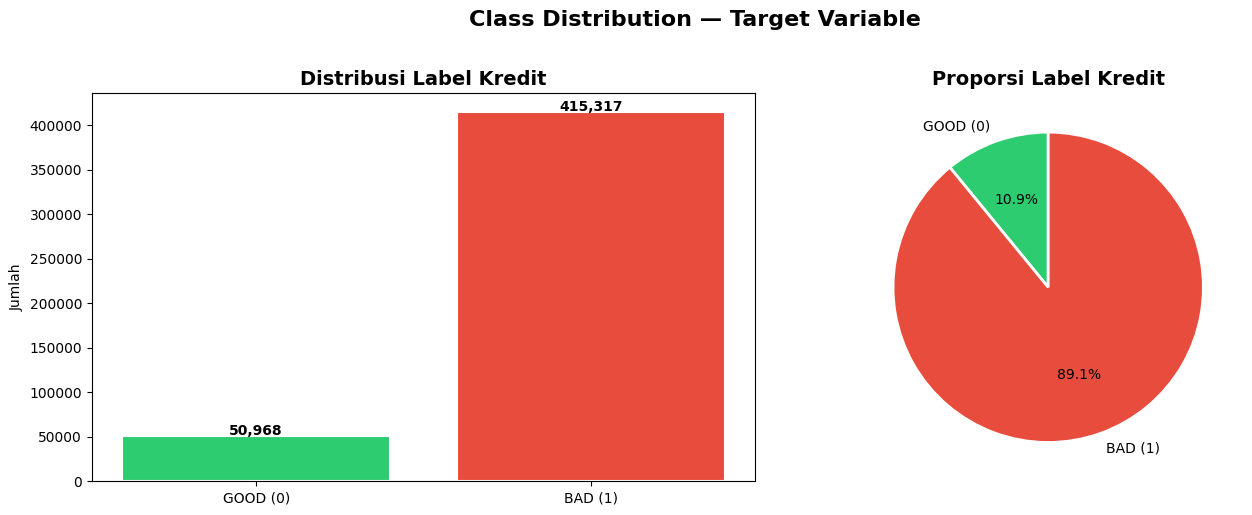

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
counts = df['loan_label'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['GOOD (0)', 'BAD (1)'], counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Distribusi Label Kredit', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['GOOD (0)', 'BAD (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Label Kredit', fontsize=14, fontweight='bold')

plt.suptitle('Class Distribution — Target Variable', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Dari visualisasi di atas ditampilkan distribusi data dari pengelompokkan nilai good dan bad, dimana proporsi label bad sendiri hanya memiliki **10.9%**, sedangkan untuk nilai good ada pada **89.1%**. Ini menandakan adanya **data imbalance**, sehingga perlu dilakukan oversampling (SMOTE) untuk label bad, agar tidak terjadi bias dalam proses training model.

C:\Users\Rafa\AppData\Local\Temp\ipykernel_9796\2247804311.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([good, bad], labels=['GOOD', 'BAD'], patch_artist=True,


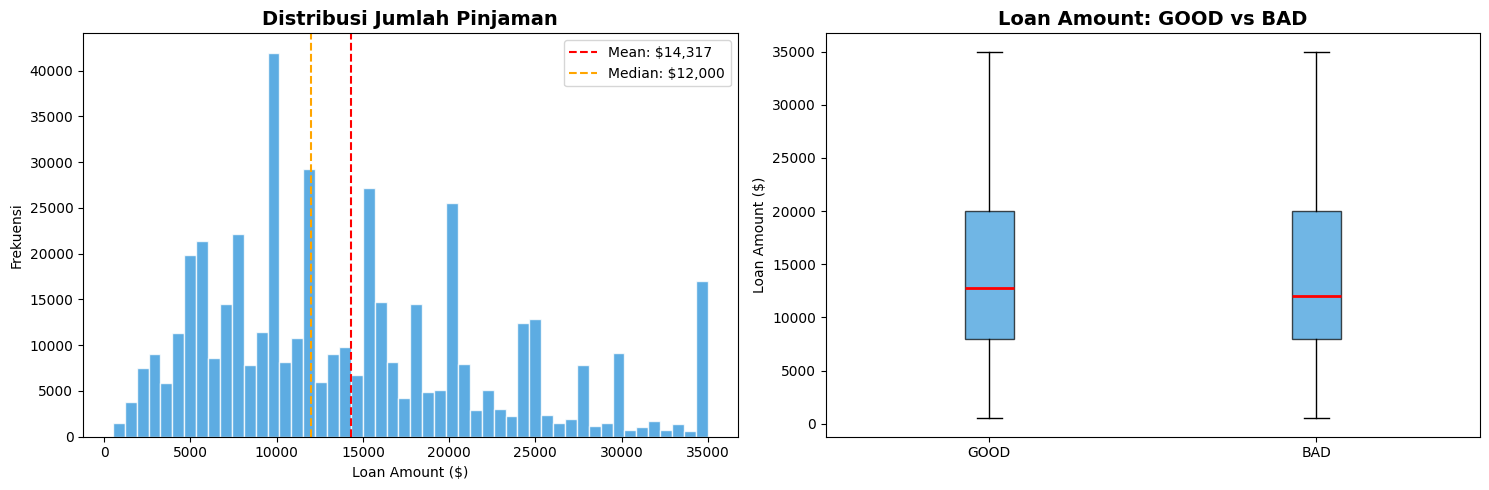

Mean  Loan Amount: $14,317.28
Median Loan Amount: $12,000.00


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram keseluruhan
axes[0].hist(df_model['loan_amnt'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribusi Jumlah Pinjaman', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Loan Amount ($)')
axes[0].set_ylabel('Frekuensi')
axes[0].axvline(df_model['loan_amnt'].mean(), color='red', linestyle='--', label=f'Mean: ${df_model["loan_amnt"].mean():,.0f}')
axes[0].axvline(df_model['loan_amnt'].median(), color='orange', linestyle='--', label=f'Median: ${df_model["loan_amnt"].median():,.0f}')
axes[0].legend()

# Boxplot by label
good = df_model[df_model['loan_label']==0]['loan_amnt']
bad  = df_model[df_model['loan_label']==1]['loan_amnt']
axes[1].boxplot([good, bad], labels=['GOOD', 'BAD'], patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Loan Amount: GOOD vs BAD', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Loan Amount ($)')

plt.tight_layout()
plt.show()

print(f'Mean  Loan Amount: ${df_model["loan_amnt"].mean():,.2f}')
print(f'Median Loan Amount: ${df_model["loan_amnt"].median():,.2f}')

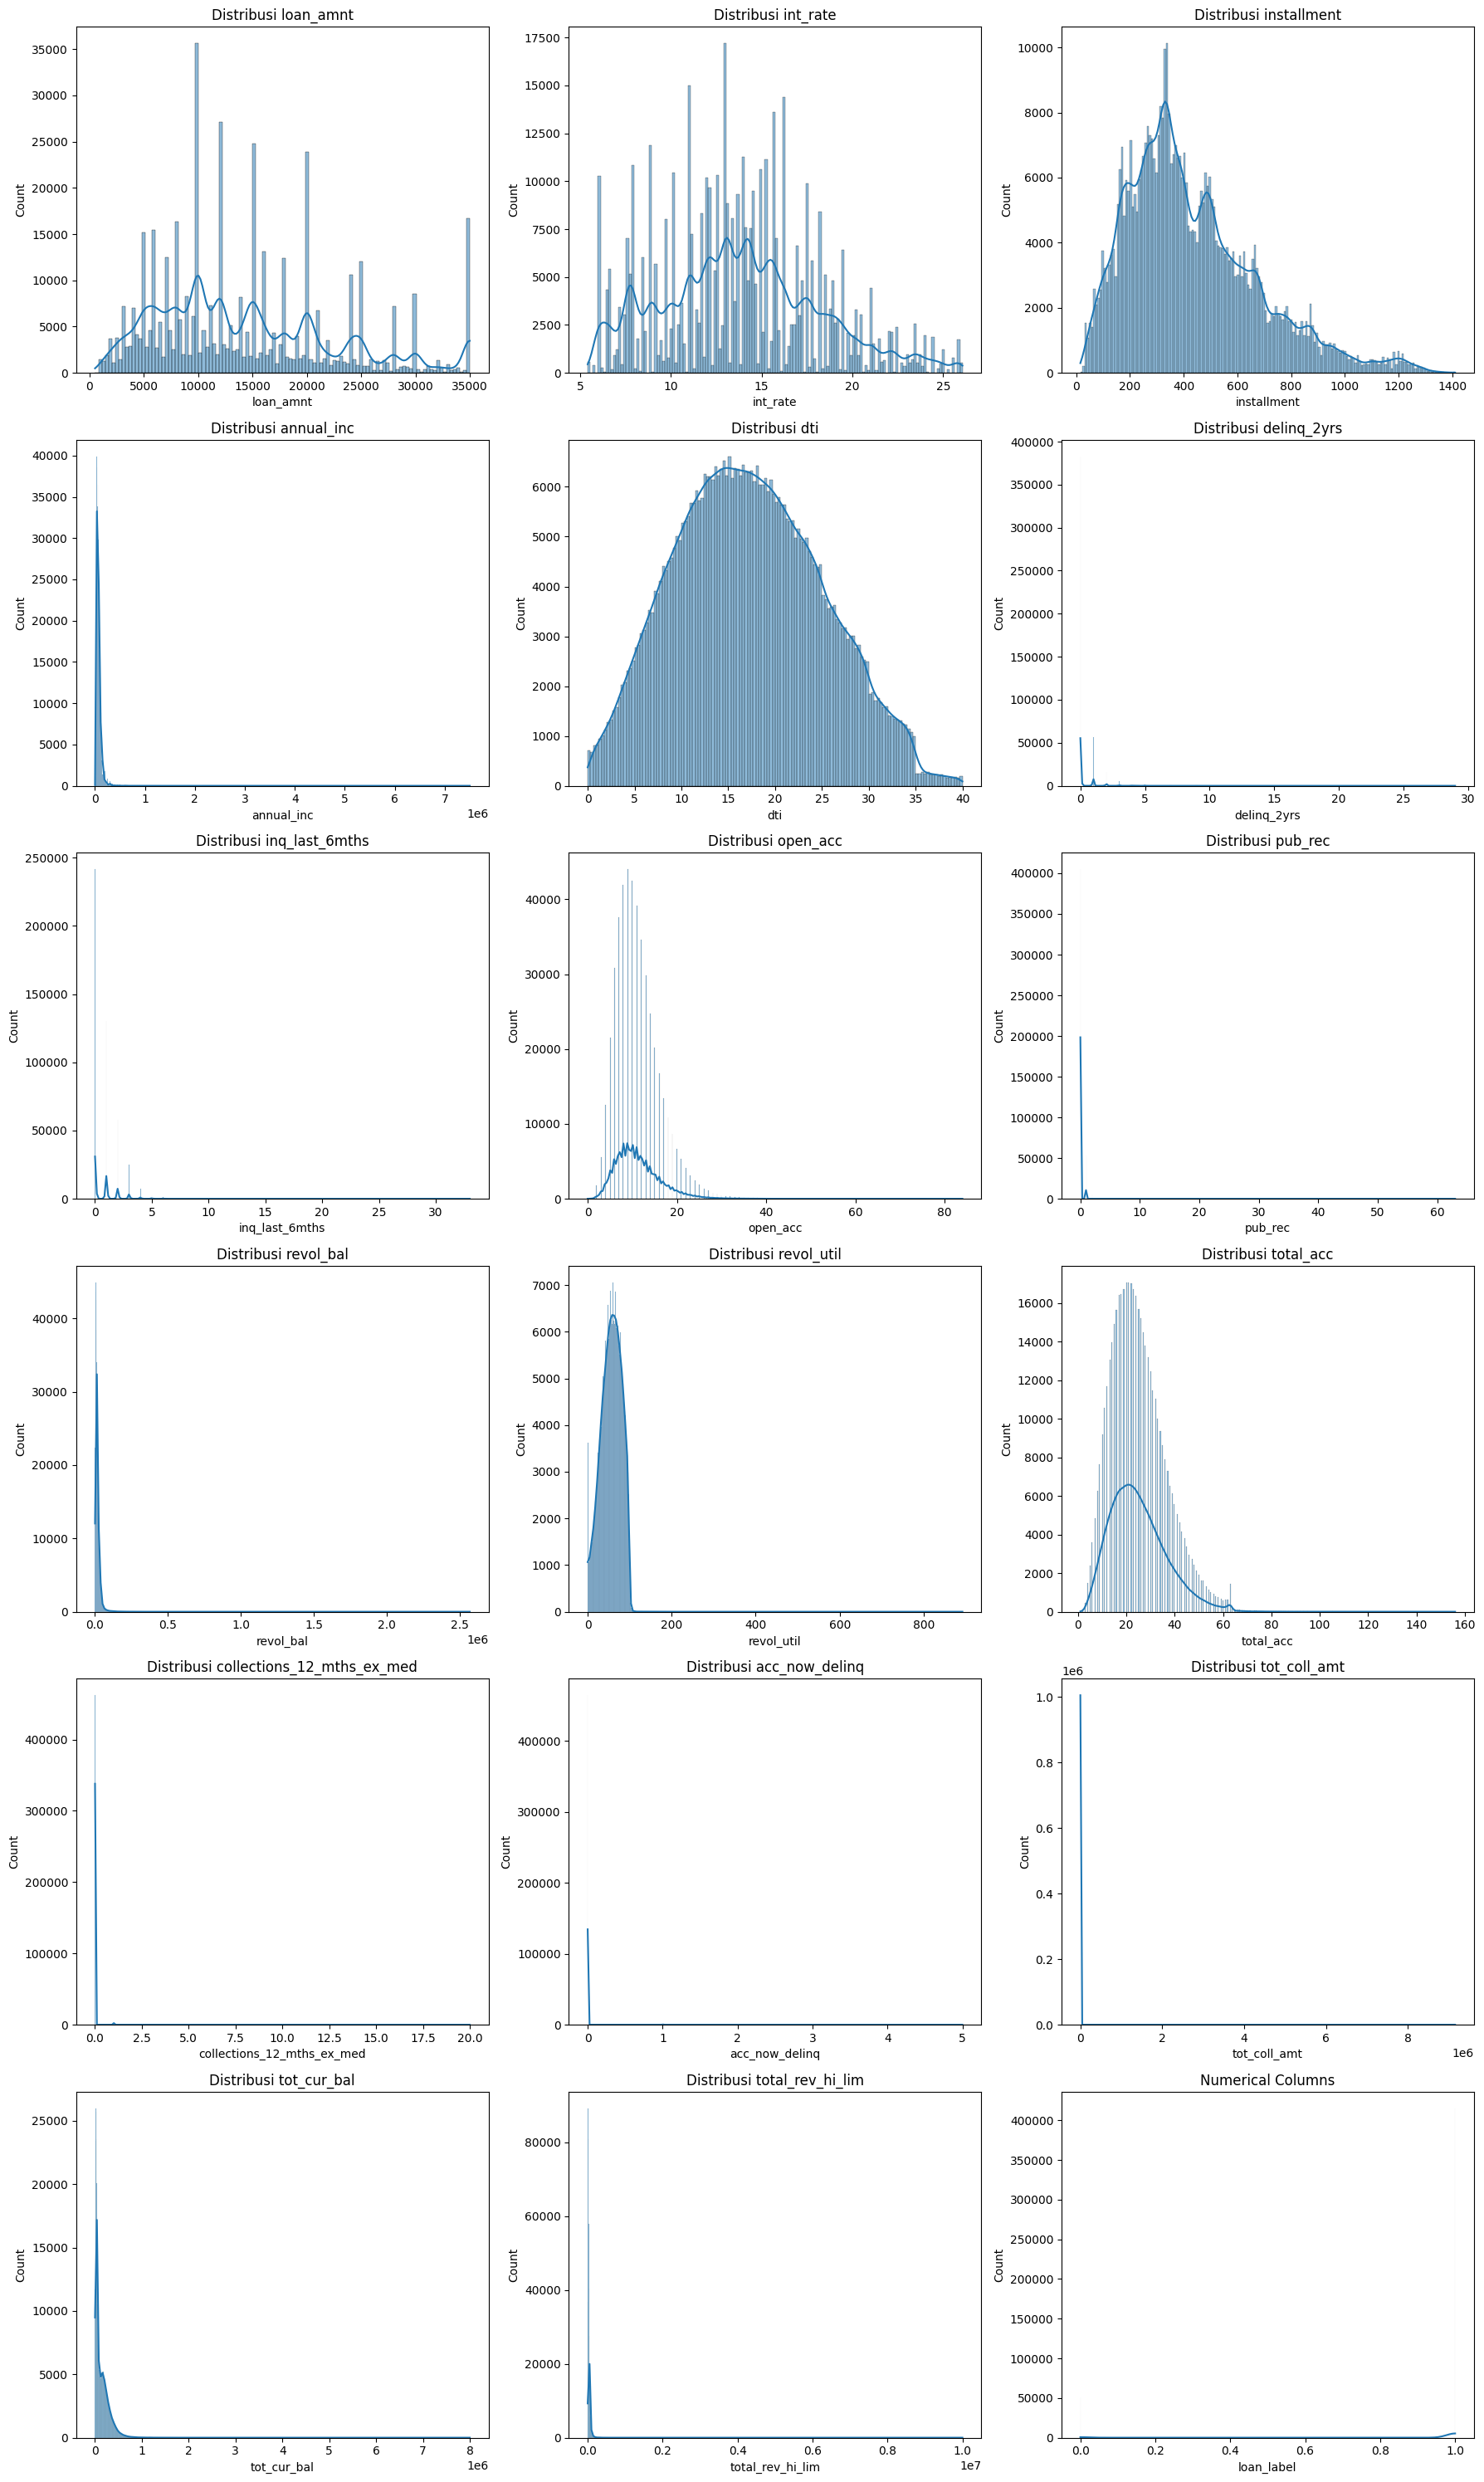

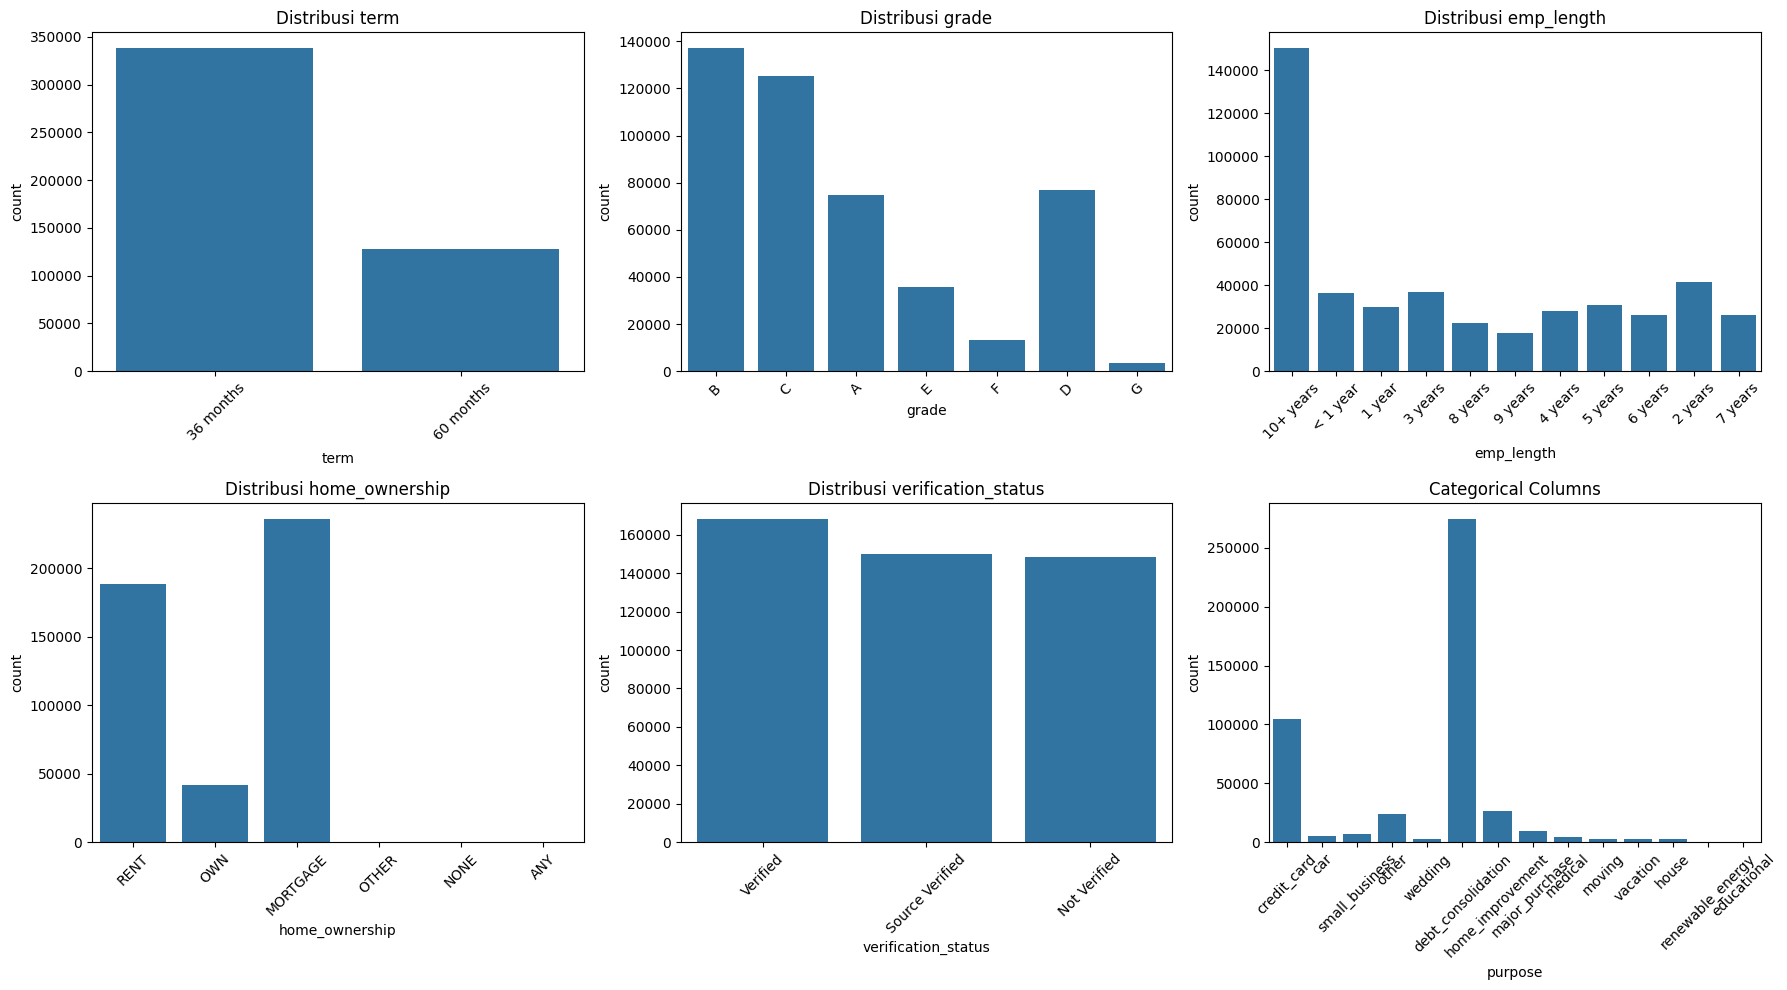

In [97]:
import math
num_cols = df_model.select_dtypes(include='number').columns.tolist()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()

# numerical cols
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df_model[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.title('Numerical Columns')
plt.show()

# categorical cols
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df_model, x=col, ax=axes[i])
    axes[i].set_title(f'Distribusi {col}')
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.title('Categorical Columns')
plt.show()


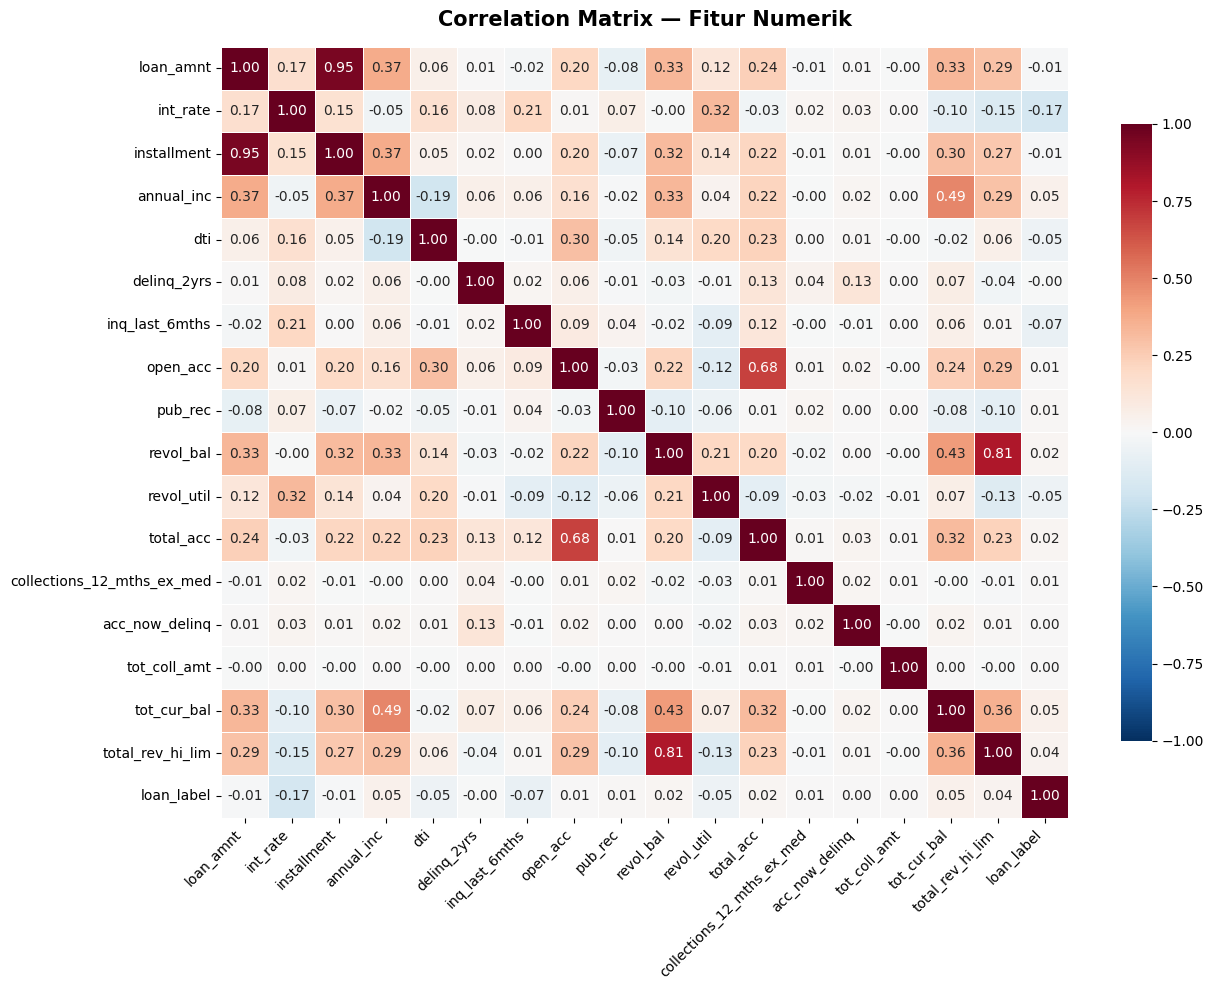


Korelasi Fitur dengan Target (loan_label):
loan_label                    1.000000
tot_cur_bal                   0.051197
annual_inc                    0.049864
total_rev_hi_lim              0.037165
total_acc                     0.023069
revol_bal                     0.018348
pub_rec                       0.009111
open_acc                      0.006174
collections_12_mths_ex_med    0.005114
tot_coll_amt                  0.001209
acc_now_delinq                0.000197
delinq_2yrs                  -0.001227
loan_amnt                    -0.011819
installment                  -0.013936
dti                          -0.048102
revol_util                   -0.050207
inq_last_6mths               -0.073102
int_rate                     -0.172361
Name: loan_label, dtype: float64


In [98]:
corr_matrix = df_model[num_cols].corr()
plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Fitur Numerik', fontsize=15, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('\nKorelasi Fitur dengan Target (loan_label):')
print(corr_matrix['loan_label'].sort_values(ascending=False))

#### DATA MODELLING

In [99]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amnt                   466285 non-null  int64  
 1   term                        466285 non-null  object 
 2   int_rate                    466285 non-null  float64
 3   installment                 466285 non-null  float64
 4   grade                       466285 non-null  object 
 5   emp_length                  445277 non-null  object 
 6   home_ownership              466285 non-null  object 
 7   annual_inc                  466281 non-null  float64
 8   verification_status         466285 non-null  object 
 9   purpose                     466285 non-null  object 
 10  dti                         466285 non-null  float64
 11  delinq_2yrs                 466256 non-null  float64
 12  inq_last_6mths              466256 non-null  float64
 13  open_acc      

##### FEATURE ENGINEERING

In [100]:
df_model['term'] = df_model['term'].str.extract(r'(\d+)').astype(float)

emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3,
    '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7,
    '8 years': 8, '9 years': 9, '10+ years': 10
}
df_model['emp_length'] = df_model['emp_length'].map(emp_map)

grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_model['grade'] = df_model['grade'].map(grade_map)

df_model['annual_inc_log']  = np.log1p(df_model['annual_inc'])
df_model['revol_bal_log']   = np.log1p(df_model['revol_bal'])
df_model['tot_cur_bal_log'] = np.log1p(df_model['tot_cur_bal'])
df_model.drop(columns=['annual_inc', 'revol_bal', 'tot_cur_bal'], inplace=True)

print(df_model.dtypes)


loan_amnt                       int64
term                          float64
int_rate                      float64
installment                   float64
grade                           int64
emp_length                    float64
home_ownership                 object
verification_status            object
purpose                        object
dti                           float64
delinq_2yrs                   float64
inq_last_6mths                float64
open_acc                      float64
pub_rec                       float64
revol_util                    float64
total_acc                     float64
collections_12_mths_ex_med    float64
acc_now_delinq                float64
tot_coll_amt                  float64
total_rev_hi_lim              float64
loan_label                      int64
annual_inc_log                float64
revol_bal_log                 float64
tot_cur_bal_log               float64
dtype: object


In [101]:
df_model.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,verification_status,purpose,dti,...,revol_util,total_acc,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,total_rev_hi_lim,loan_label,annual_inc_log,revol_bal_log,tot_cur_bal_log
0,5000,36.0,10.65,162.87,2,10.0,RENT,Verified,credit_card,27.65,...,83.7,9.0,0.0,0.0,NaN,NaN,1,10.085851,9.521422,NaN
1,2500,60.0,15.27,59.83,3,0.0,RENT,Source Verified,car,1.00,...,9.4,4.0,0.0,0.0,NaN,NaN,0,10.308986,7.431300,NaN
2,2400,36.0,15.96,84.33,3,10.0,RENT,Not Verified,small_business,8.72,...,98.5,10.0,0.0,0.0,NaN,NaN,1,9.413526,7.991931,NaN
3,10000,36.0,13.49,339.31,3,10.0,RENT,Source Verified,other,20.00,...,21.0,37.0,0.0,0.0,NaN,NaN,1,10.803669,8.630343,NaN
4,3000,60.0,12.69,67.79,2,1.0,RENT,Source Verified,other,17.94,...,53.9,38.0,0.0,0.0,NaN,NaN,1,11.289794,10.232216,NaN


In [102]:
# Rasio cicilan terhadap pendapatan (kemampuan bayar)
df_model['loan_to_inc']        = df_model['loan_amnt'] / (np.expm1(df_model['annual_inc_log']) + 1)
# Tekanan finansial gabungan
df_model['rate_x_dti']         = df_model['int_rate'] * df_model['dti']
# Beban bunga terhadap grade
df_model['grade_x_rate'] = df_model['grade'] * df_model['int_rate']
# Utilisasi kartu kredit vs pendapatan
df_model['util_per_inc']       = df_model['revol_util'] / (df_model['annual_inc_log'] + 1)
# Riwayat buruk keseluruhan
df_model['bad_history_score']  = df_model['delinq_2yrs'] + df_model['pub_rec'] + df_model['acc_now_delinq']
# Enquiry baru (sinyal butuh uang)
df_model['inq_ratio']          = df_model['inq_last_6mths'] / (df_model['total_acc'] + 1)

print(f'Total fitur setelah engineering: {df_model.shape[1] - 1}')
print('Fitur baru:', ['loan_to_inc', 'rate_x_dti', 'grade_x_rate', 
                      'util_per_inc', 'bad_history_score', 'inq_ratio'])

Total fitur setelah engineering: 29
Fitur baru: ['loan_to_inc', 'rate_x_dti', 'grade_x_rate', 'util_per_inc', 'bad_history_score', 'inq_ratio']


In [103]:
df_model.columns

Index(['loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'emp_length',
       'home_ownership', 'verification_status', 'purpose', 'dti',
       'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util',
       'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq',
       'tot_coll_amt', 'total_rev_hi_lim', 'loan_label', 'annual_inc_log',
       'revol_bal_log', 'tot_cur_bal_log', 'loan_to_inc', 'rate_x_dti',
       'grade_x_rate', 'util_per_inc', 'bad_history_score', 'inq_ratio'],
      dtype='object')

##### HANDLING MISSING VALUES

In [104]:
print('Missing values sebelum imputasi:')
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

num_cols = df_model.select_dtypes(include=['number']).columns.tolist()
num_cols = [c for c in num_cols if c != 'loan_label']

for col in num_cols:
    if df_model[col].isnull().sum() > 0:
        median_val = df_model[col].median()
        df_model[col] = df_model[col].fillna(median_val)

# Imputasi kategorik dengan modus
for col in cat_cols:
    if df_model[col].isnull().sum() > 0:
        mode_val = df_model[col].mode()[0]
        df_model[col] = df_model[col].fillna(mode_val)

print('\nMissing values setelah imputasi:')
print(df_model.isnull().sum().sum())

Missing values sebelum imputasi:
emp_length                    21008
delinq_2yrs                      29
inq_last_6mths                   29
open_acc                         29
pub_rec                          29
revol_util                      340
total_acc                        29
collections_12_mths_ex_med      145
acc_now_delinq                   29
tot_coll_amt                  70276
total_rev_hi_lim              70276
annual_inc_log                    4
tot_cur_bal_log               70276
loan_to_inc                       4
util_per_inc                    340
bad_history_score                29
inq_ratio                        29
dtype: int64

Missing values setelah imputasi:
0


In [105]:
df_model.head()

,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,verification_status,purpose,dti,...,loan_label,annual_inc_log,revol_bal_log,tot_cur_bal_log,loan_to_inc,rate_x_dti,grade_x_rate,util_per_inc,bad_history_score,inq_ratio
0,5000,36.0,10.65,162.87,2,10.0,RENT,Verified,credit_card,27.65,...,1,10.085851,9.521422,11.308849,0.208325,294.4725,21.30,7.550165,0.0,0.100000
1,2500,60.0,15.27,59.83,3,0.0,RENT,Source Verified,car,1.00,...,0,10.308986,7.431300,11.308849,0.083331,15.2700,45.81,0.831197,0.0,1.000000
2,2400,36.0,15.96,84.33,3,10.0,RENT,Not Verified,small_business,8.72,...,1,9.413526,7.991931,11.308849,0.195870,139.1712,47.88,9.458852,0.0,0.181818
3,10000,36.0,13.49,339.31,3,10.0,RENT,Source Verified,other,20.00,...,1,10.803669,8.630343,11.308849,0.203248,269.8000,40.47,1.779108,0.0,0.026316
4,3000,60.0,12.69,67.79,2,1.0,RENT,Source Verified,other,17.94,...,1,11.289794,10.232216,11.308849,0.037500,227.6586,25.38,4.385753,0.0,0.000000


In [106]:
# One-Hot Encoding untuk
df_model = pd.get_dummies(df_model, columns=['home_ownership', 'verification_status', 'purpose'],
                          drop_first=True)

print(f' Setelah encoding: {df_model.shape[1]} kolom')
print('Kolom baru:', [c for c in df_model.columns if any(x in c for x in ['home_', 'verif_', 'purpose_'])][:10])

 Setelah encoding: 47 kolom
Kolom baru: ['home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_educational', 'purpose_home_improvement', 'purpose_house']


In [107]:
df_model.shape

(466285, 47)

##### Split Data & Train Test


In [108]:
target = 'loan_label'

X = df_model.drop(columns=[target])
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Split selesai:')
print(f'  Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'  Train BAD rate: {y_train.mean()*100:.2f}%')
print(f'  Test  BAD rate: {y_test.mean()*100:.2f}%')

Split selesai:
  Train: 373,028 | Test: 93,257
  Train BAD rate: 89.07%
  Test  BAD rate: 89.07%


##### FEATURE SCALING


In [109]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

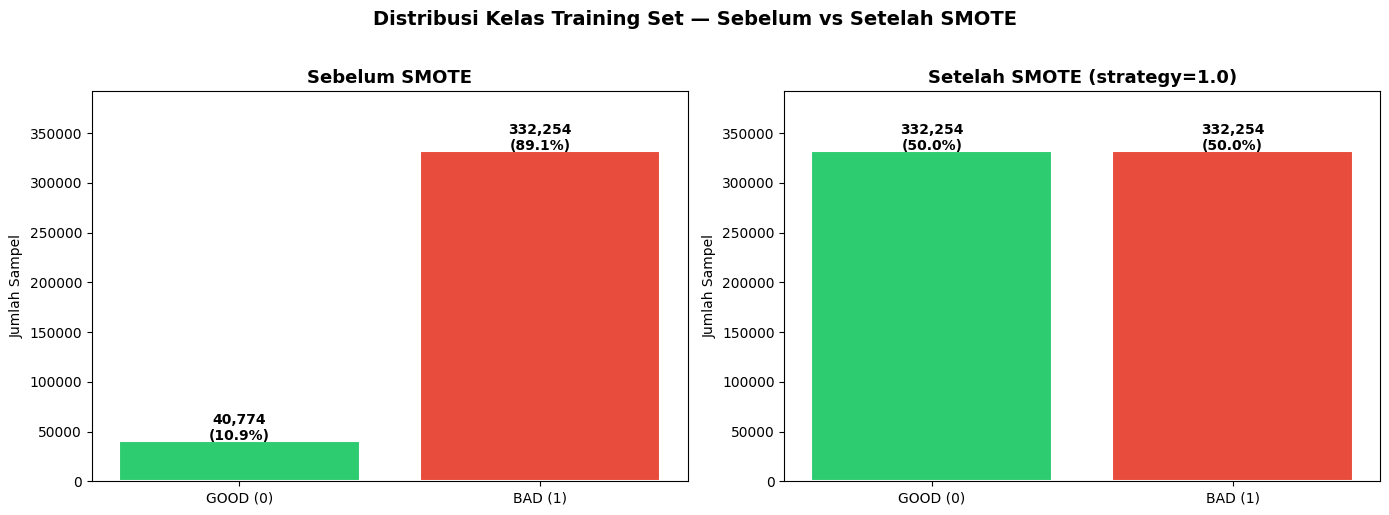

 SMOTE Final (strategy=1.0):
 GOOD : 332,254
 BAD  : 332,254
 Rasio: 1.000

 Data BAD sintetis : 0 (0.0% dari total BAD)
 Data BAD asli     : 332,254 (100.0% dari total BAD)


In [111]:
# SMOTE
smote_final = SMOTE(sampling_strategy=1.0, random_state=42)
X_train_res, y_train_res = smote_final.fit_resample(X_train_scaled, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, counts, title in [
    (axes[0], pd.Series(y_train).value_counts().sort_index(),  'Sebelum SMOTE'),
    (axes[1], pd.Series(y_train_res).value_counts().sort_index(), 'Setelah SMOTE (strategy=1.0)')
]:
    bars = ax.bar(['GOOD (0)', 'BAD (1)'], counts.values,
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah Sampel')
    ax.set_ylim(0, max(counts.values) * 1.18)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v + 1000,
                f'{v:,}\n({v/sum(counts.values)*100:.1f}%)',
                ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Distribusi Kelas Training Set — Sebelum vs Setelah SMOTE',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

bad_synthetic = (y_train_res == 1).sum() - (y_train == 1).sum()
bad_total_after = (y_train_res == 1).sum()
print(f' SMOTE Final (strategy=1.0):')
print(f' GOOD : {(y_train_res==0).sum():,}')
print(f' BAD  : {(y_train_res==1).sum():,}')
print(f' Rasio: {(y_train_res==1).sum()/(y_train_res==0).sum():.3f}')
print(f'\n Data BAD sintetis : {bad_synthetic:,} ({bad_synthetic/bad_total_after*100:.1f}% dari total BAD)')
print(f' Data BAD asli     : {(y_train==1).sum():,} ({(y_train==1).sum()/bad_total_after*100:.1f}% dari total BAD)')

In [112]:
# Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  
    random_state=42,
    C=1.0,                   
    solver='lbfgs'
)

lr_model.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [114]:
# Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)

,n_estimators,300
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [115]:
def evaluate_model(model, X_test, y_test, model_name, color):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    auc    = roc_auc_score(y_test, y_prob)
    acc    = accuracy_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred)
    rec    = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)

    print(f'\n{'='*55}')
    print(f'  📊 {model_name}')
    print(f'{'='*55}')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'\n{classification_report(y_test, y_pred, target_names=["GOOD", "BAD"])}')

    return y_pred, y_prob, auc

# Evaluasi kedua model
lr_pred, lr_prob, lr_auc = evaluate_model(lr_model, X_test_scaled, y_test, 'Logistic Regression', '#3498db')
rf_pred, rf_prob, rf_auc = evaluate_model(rf_model, X_test_scaled, y_test, 'Random Forest', '#2ecc71')


  📊 Logistic Regression
  ROC-AUC  : 0.6783
  Accuracy : 0.6065
  Precision: 0.9348
  Recall   : 0.6001
  F1-Score : 0.7309

              precision    recall  f1-score   support

        GOOD       0.17      0.66      0.27     10194
         BAD       0.93      0.60      0.73     83063

    accuracy                           0.61     93257
   macro avg       0.55      0.63      0.50     93257
weighted avg       0.85      0.61      0.68     93257


  📊 Random Forest
  ROC-AUC  : 0.6738
  Accuracy : 0.7579
  Precision: 0.9155
  Recall   : 0.8022
  F1-Score : 0.8551

              precision    recall  f1-score   support

        GOOD       0.20      0.40      0.26     10194
         BAD       0.92      0.80      0.86     83063

    accuracy                           0.76     93257
   macro avg       0.56      0.60      0.56     93257
weighted avg       0.84      0.76      0.79     93257

